# NHL Expected Goals (xG) Model — A Spatio-Temporal Shot Model

This notebook builds a shot-quality ("expected goals") model for NHL shots using spatio-temporal features: where on the ice the shot was taken (space) combined
with when in the game it happened and the score/strength context at that moment (time).

Data comes directly from the NHL's public play-by-play API.

**Pipeline:** fetch play-by-play -> extract shot events -> engineer spatio-temporal
features -> train a gradient-boosted classifier and a logistic-regression
baseline on the same train/test split -> compare -> visualize.


In [1]:
import sys
sys.path.insert(0, "src")

import datetime
from fetch_data import fetch_shots_for_date_range
from features import build_features
from model import split_data, train_xgb, train_logistic
from visualize import plot_shot_map, plot_cumulative_xg

import pandas as pd
import matplotlib.pyplot as plt


## 1. Pull shot data

Two weeks (14 days). 

In [ ]:
START_DATE = datetime.date(2024, 1, 1)
NUM_DAYS = 14  

DATES = [(START_DATE + datetime.timedelta(days=i)).isoformat() for i in range(NUM_DAYS)]
print(f"Fetching shots from {DATES[0]} to {DATES[-1]} ({NUM_DAYS} days)...")

raw_rows = fetch_shots_for_date_range(DATES)
print(f"Pulled {len(raw_rows)} shot events across {NUM_DAYS} day(s)")


Fetching shots from 2024-01-01 to 2024-01-14 (14 days)...


Pulled 12093 shot events across 14 day(s)


## 2. Engineer spatio-temporal features

- **Spatial:** shot distance and angle to the net (derived from x/y rink coordinates)
- **Temporal:** elapsed game time in seconds, period, score differential and
  strength state at the moment of the shot. 


In [3]:
df = build_features(raw_rows)
print(df.shape)
print(f"Goal rate: {df['target'].mean():.3%}")
df.head()


(12093, 13)
Goal rate: 4.986%


,distance_ft,angle_deg,game_elapsed_s,score_diff,period,shot_type,strength_state,target,game_id,event_id,x,y,is_home_team_shot
0,28.460499,71.565049,47,0,1,wrist,5v5,0,2023020573,156,80,-27,False
1,52.239832,5.492324,54,0,1,unknown,5v5,0,2023020573,157,37,-5,False
2,44.777226,29.427456,61,0,1,wrist,5v5,0,2023020573,159,-50,22,True
3,54.378304,32.228757,69,0,1,unknown,5v5,0,2023020573,161,43,-29,False
4,38.209946,6.009006,101,0,1,unknown,5v5,0,2023020573,170,-51,4,True


## 3. Train two models on the same train/test split

- **XGBoost** — gradient-boosted trees, the primary model.
- **Logistic regression** — a simple, interpretable linear baseline.

Training both on an identical split isolates how much predictive lift the
gradient-boosted model actually provides over a much simpler linear model.


In [4]:
X_train, X_test, y_train, y_test = split_data(df)

xgb_pipeline, xgb_metrics, xgb_proba = train_xgb(X_train, X_test, y_train, y_test)
log_pipeline, log_metrics, log_proba = train_logistic(X_train, X_test, y_train, y_test)

comparison = pd.DataFrame([
    {"model": "XGBoost", **xgb_metrics},
    {"model": "Logistic Regression", **log_metrics},
]).set_index("model")
comparison


,roc_auc,log_loss,brier_score,n_test,goal_rate_test
model,,,,,
XGBoost,0.820746,0.164327,0.044450,2419,0.050021
Logistic Regression,0.826813,0.161897,0.043788,2419,0.050021


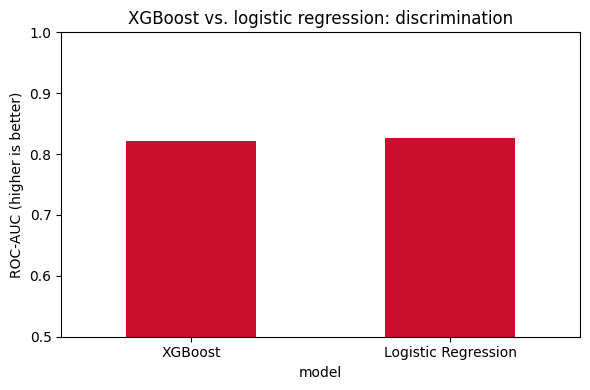

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison[["roc_auc"]].plot(kind="bar", ax=ax, legend=False, color=["#c8102e", "#8c8c8c"])
ax.set_ylabel("ROC-AUC (higher is better)")
ax.set_title("XGBoost vs. logistic regression: discrimination")
ax.set_ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Visualize

Using the XGBoost model's predictions. The shot map shows where  xG is
highest (close, central shots). The cumulative xG chart shows when each
team generated their scoring chances over the course of a game.

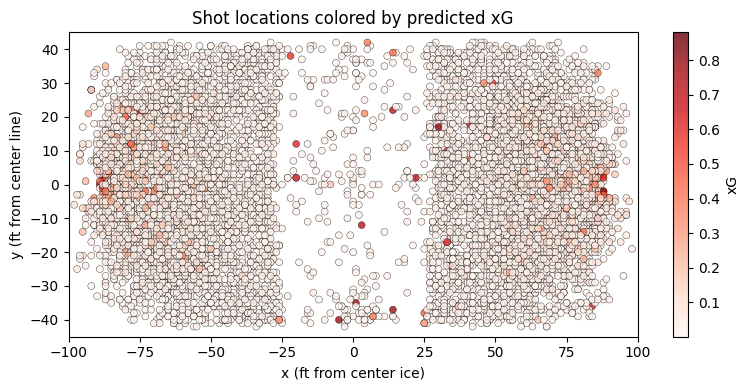

In [6]:
df["xg"] = xgb_pipeline.predict_proba(df[X_test.columns])[:, 1]

fig, ax = plt.subplots(figsize=(8, 4))
plot_shot_map(df, ax=ax)
plt.tight_layout()
plt.show()


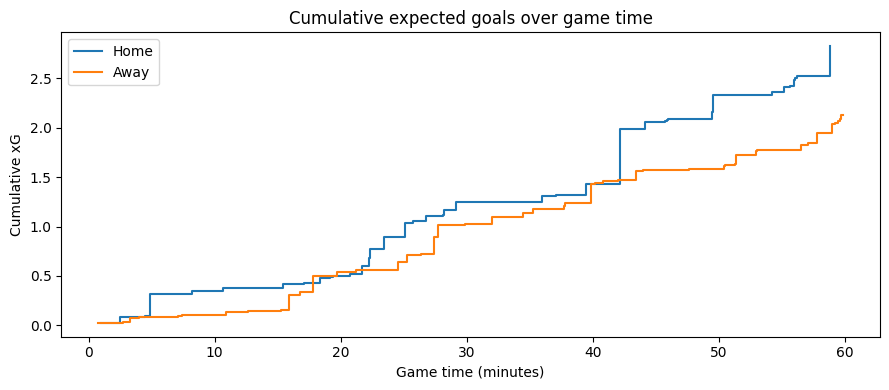

In [ ]:
# One game to show the cumulative xG race over time
example_game_id = df["game_id"].iloc[0]
game_df = df[df["game_id"] == example_game_id]

fig, ax = plt.subplots(figsize=(9, 4))
plot_cumulative_xg(game_df, ax=ax)
plt.tight_layout()
plt.show()
